In [3]:
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import numpy as np
from PIL import Image
from glob import glob
import os


In [4]:
# Define the Autoencoder class
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),  # 1024x1024 -> 512x512
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),  # 512x512 -> 256x256
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),  # 256x256 -> 128x128
            nn.ReLU(),
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),  # 128x128 -> 64x64
            nn.ReLU(),
            nn.Conv2d(512, 1024, kernel_size=4, stride=2, padding=1),  # 64x64 -> 32x32
            nn.ReLU(),
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(1024, 512, kernel_size=4, stride=2, padding=1),  # 32x32 -> 64x64
            nn.ReLU(),
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),  # 64x64 -> 128x128
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),  # 128x128 -> 256x256
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 256x256 -> 512x512
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1),  # 512x512 -> 1024x1024
            nn.Sigmoid(),  # Output in range [0, 1]
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [5]:
# Dataset class
class CustomDataset(Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image

In [14]:
# Training loop
def train_autoencoder(model, dataloader, criterion, optimizer, epochs=10):
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0.0
        for images in dataloader:
            images = images.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, images)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        print(f"Epoch [{epoch + 1}/{epochs}], Loss: {epoch_loss / len(dataloader):.4f}")
    return model

# To train the model:
# train_autoencoder(model, dataloader, criterion, optimizer, epochs=20)

# Save the trained model
# torch.save(model.state_dict(), 'autoencoder.pth')


In [15]:
# Transform for resizing and normalization
transform = transforms.Compose([
    transforms.Resize((1024, 1024)),
    transforms.ToTensor(),
])

# Instantiate model, loss function, and optimizer
model = Autoencoder()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.MSELoss()  # Reconstruction loss
optimizer = optim.Adam(model.parameters(), lr=1e-4)

image_paths = glob(os.path.join("/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_images/11_063_CG_aSyn_x200.svs/grey","*.png"))
dataset = CustomDataset(image_paths, transform=transform)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

In [16]:
model = train_autoencoder(model, dataloader, criterion, optimizer, epochs=10)

Epoch [1/10], Loss: 0.0150
Epoch [2/10], Loss: 0.0033
Epoch [3/10], Loss: 0.0026
Epoch [4/10], Loss: 0.0023
Epoch [5/10], Loss: 0.0020
Epoch [6/10], Loss: 0.0019
Epoch [7/10], Loss: 0.0018
Epoch [8/10], Loss: 0.0017
Epoch [9/10], Loss: 0.0016
Epoch [10/10], Loss: 0.0016


In [17]:
def test_autoencoder(model, image_path, transform):
    model.eval()
    image = Image.open(image_path).convert('RGB')
    input_image = transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        reconstructed = model(input_image).squeeze(0).cpu()
        reconstructed_image = transforms.ToPILImage()(reconstructed)
        
    return reconstructed_image

In [18]:
image_path = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_images_RedMarked/PD001_Syn1_CG.svs/grey/PD001_Syn1_CG.svs_x_9989_y_15291.png"
gen_output = test_autoencoder(model, image_path, transform)

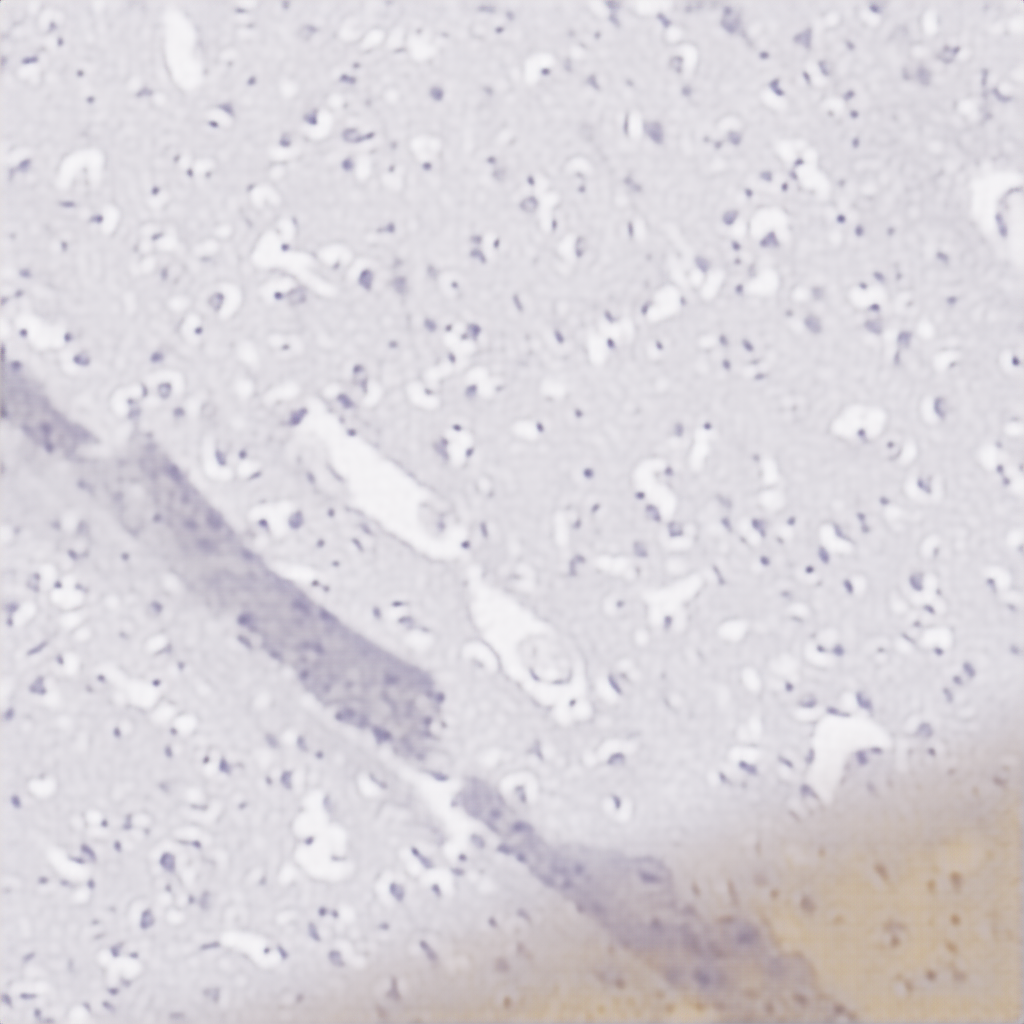

In [19]:
gen_output